In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import scanpy as sc
from driver_genes.data.utils import compute_pred

sns.set_theme(style='ticks')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42


def valid_fname(fname):
    # Remove LaTeX syntax like \text{xxx}, replace with xxx
    fname = re.sub(r'\\text\{([^}]+)\}', r'\1', fname)
    # Remove all other LaTeX math and special symbols, e.g. $, ^, _, {, }, \, etc.
    fname = re.sub(r'\\[a-zA-Z]+', '', fname)  # remove remaining LaTeX commands like \gamma
    fname = re.sub(r'[\$\^\{\}\\]', '', fname) # remove $, ^, {, }, \
    # Replace multiple spaces/dashes/underscores with single underscore
    fname = re.sub(r'[\s\-]+', '_', fname)
    # Remove any other non-alphanumeric, non-dot, non-underscore
    fname = re.sub(r'[^a-zA-Z0-9_.]', '_', fname)
    return fname

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

In [2]:
padata = sc.concat([
    sc.read_h5ad('../results/tcells/overlappedgenes2-seed42/anndata/preprocessed_Naive.h5ad'),
    sc.read_h5ad('../results/tcells/overlappedgenes2-seed42/anndata/preprocessed_Memory.h5ad'),
])

In [3]:
marker_genes = {
    r'$\text{IL-2}^\text{hi}$': ['IL2', 'IL21', 'G0S2', 'SP140', 'MYC'],#,  "CD69", "REL"],
    r'$\text{IFN}\gamma^\text{hi}$': ['IFNG', 'CCL3', 'CCL4', 'CCL4L2'],#, "CXCR3", "CCR5", "CCL5"],
    r'$\text{T}_\text{H}2$': ['GATA3', 'MRPS26', 'LIMA1', 'SPINT2']#,  "MAOA", "PTGDR2", "IL1RL1", "IL4R"]
}
marker_genes = {ct: [g for g in mks if g in padata.var_names] for ct, mks in marker_genes.items()}
print(marker_genes)


{'$\\text{IL-2}^\\text{hi}$': ['IL2', 'IL21', 'G0S2', 'MYC'], '$\\text{IFN}\\gamma^\\text{hi}$': ['IFNG', 'CCL3', 'CCL4', 'CCL4L2'], '$\\text{T}_\\text{H}2$': ['GATA3', 'MRPS26', 'LIMA1', 'SPINT2']}


In [4]:
padata_p = padata[~(
    padata.obs['perturbation'].isin(['control', 'neg']).values | 
    padata.obs['cluster.id'].isin(['Mitotic', 'HSP.high']).values
)].copy()
padata_p.layers['log1p'] = padata_p.X.copy()
# padata_p.X = padata_p.layers['dy']
# sc.pp.highly_variable_genes(padata_p, n_top_genes=2000, flavor='seurat')
# sc.pp.pca(padata_p, n_comps=30)

In [5]:
padata_p.obs['cluster.id'].value_counts()

cluster.id
TN (Th17)             4593
TN (iTreg)            4132
TCM2 (Th17/iTreg)     3765
TEM (Th17/iTreg)      2938
TN (Th2)              2922
TN (Th17/iTreg)       2403
TCM1 (Th0)            1113
TCM2 (Th0)            1088
IFN.high              1062
TEMRA (Th17/iTreg)     981
TN (Th0)               965
TCM1 (Th17/iTreg)      944
nTreg (Th0)            702
TEM (Th0)              428
TEMRA (Th0)            149
Name: count, dtype: int64

In [6]:
driver_genes = {
    r'$\text{IL-2}^\text{hi}$': ['VAV1', 'CD28'],#, 'IL2'],
    r'$\text{IFN}\gamma^\text{hi}$': ['APOBEC3C'],
    r'$\text{T}_\text{H}2$': ['GATA3'],
}
driver_genes = {k: [g for g in v if g in padata.obsm['proba'].columns] for k, v in driver_genes.items()}
g2ct = {g: ct for ct, genes in driver_genes.items() for g in genes}
print("\n".join(f"{g}: {k}" for g,k in g2ct.items()))

VAV1: $\text{IL-2}^\text{hi}$
CD28: $\text{IL-2}^\text{hi}$
APOBEC3C: $\text{IFN}\gamma^\text{hi}$
GATA3: $\text{T}_\text{H}2$


In [7]:
compute_pred(padata_p)
padata_p.obsm['normalized_proba'] = padata_p.obsm['logit'].apply(softmax, axis=1)
assert np.isclose(padata_p.obsm['normalized_proba'].sum(axis=1), 1.0).all()

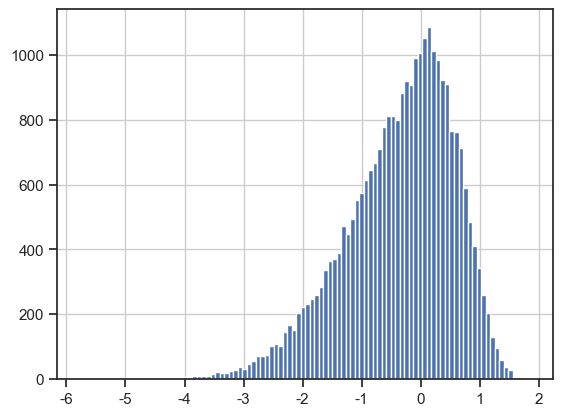

In [8]:
padata_p.obsm['proba'].sum(axis=1).map(np.log).hist(bins=100)
plt.savefig('../figures/3_tcells2_proba_sum_log_hist.pdf', bbox_inches='tight')
plt.show()


In [9]:
# sc.pp.highly_variable_genes(padata_p, n_top_genes=500, flavor='seurat')
sc.pp.pca(padata_p, n_comps=30, use_highly_variable=False)
sc.pp.neighbors(padata_p, n_neighbors=30, random_state=42)
sc.tl.umap(padata_p, random_state=42)

In [45]:
sc.tl.leiden(padata_p, random_state=0, flavor="igraph", resolution=1.5)

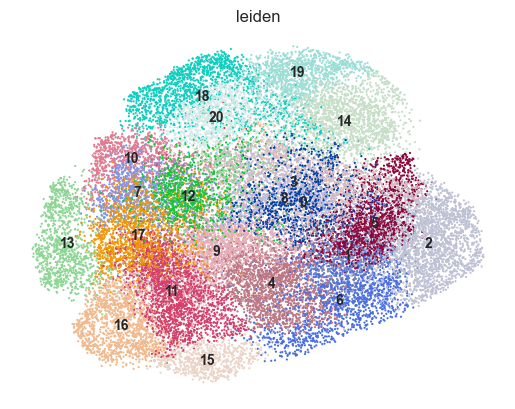

In [46]:
sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['leiden'], 
    size=10, 
    legend_fontsize=10,
    legend_loc='on data',
    frameon=False,
)


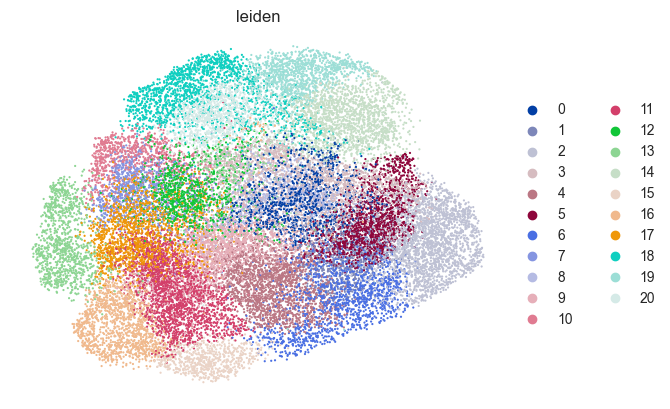

In [47]:
sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['leiden'], 
    size=10, 
    legend_fontsize=10,
    # legend_loc='on data',
    frameon=False,
)

categories: 0, 1, 2, etc.
var_group_labels: $\text{IL-2}^\text{hi}$, $\text{IFN}\gamma^\text{hi}$, $\text{T}_\text{H}2$


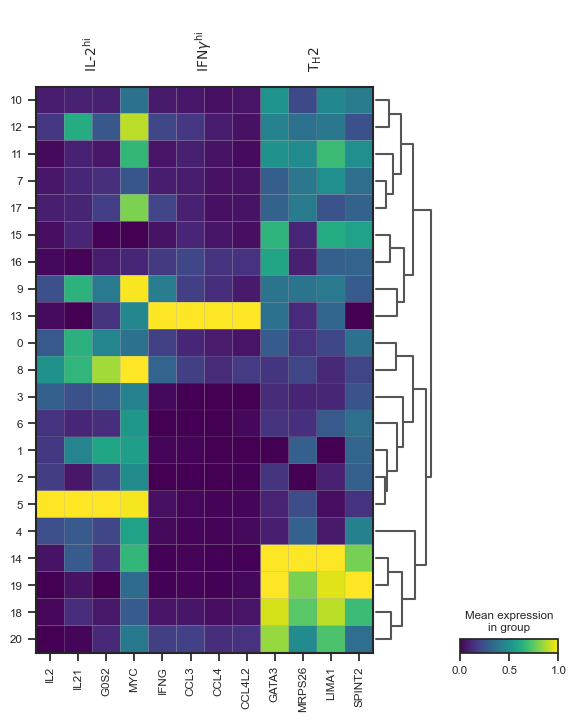

In [48]:
for unskey in list(padata_p.uns.keys()):
    if 'dendrogram' in unskey:
        del padata_p.uns[unskey]
sc.pl.matrixplot(padata_p, marker_genes, groupby='leiden', standard_scale='var', dendrogram=True)

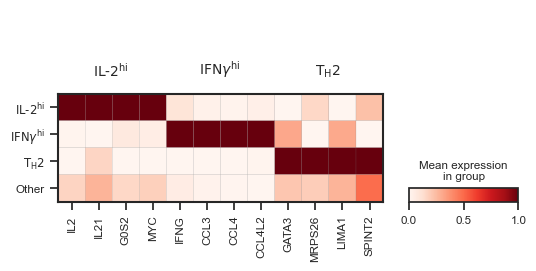

In [49]:
# annotate the above cluster by enrichment of marker genes
subtype2leiden_mapper = {
    r'$\text{IL-2}^\text{hi}$': ['5', '8'],
    r'$\text{IFN}\gamma^\text{hi}$': ['13'],
    r'$\text{T}_\text{H}2$': ['14', '19', '18', '20'],
}
leiden2subtype_mapper = {v: k for k, vs in subtype2leiden_mapper.items() for v in vs}

padata_p.obs['subtype.leiden'] = padata_p.obs['leiden'].map(lambda x: leiden2subtype_mapper.get(x, 'Other'))
ax_dict = sc.pl.matrixplot(
    padata_p,
    marker_genes, 
    groupby='subtype.leiden',
    dendrogram=False, 
    categories_order=[r'$\text{IL-2}^\text{hi}$', r'$\text{IFN}\gamma^\text{hi}$', r'$\text{T}_\text{H}2$', 'Other'],
    show=False,
    standard_scale='var',
    cmap='Reds',
    var_group_rotation=0,
)
plt.savefig('../figures/3_tcells2_subtype_markers.pdf', bbox_inches='tight')
plt.show()


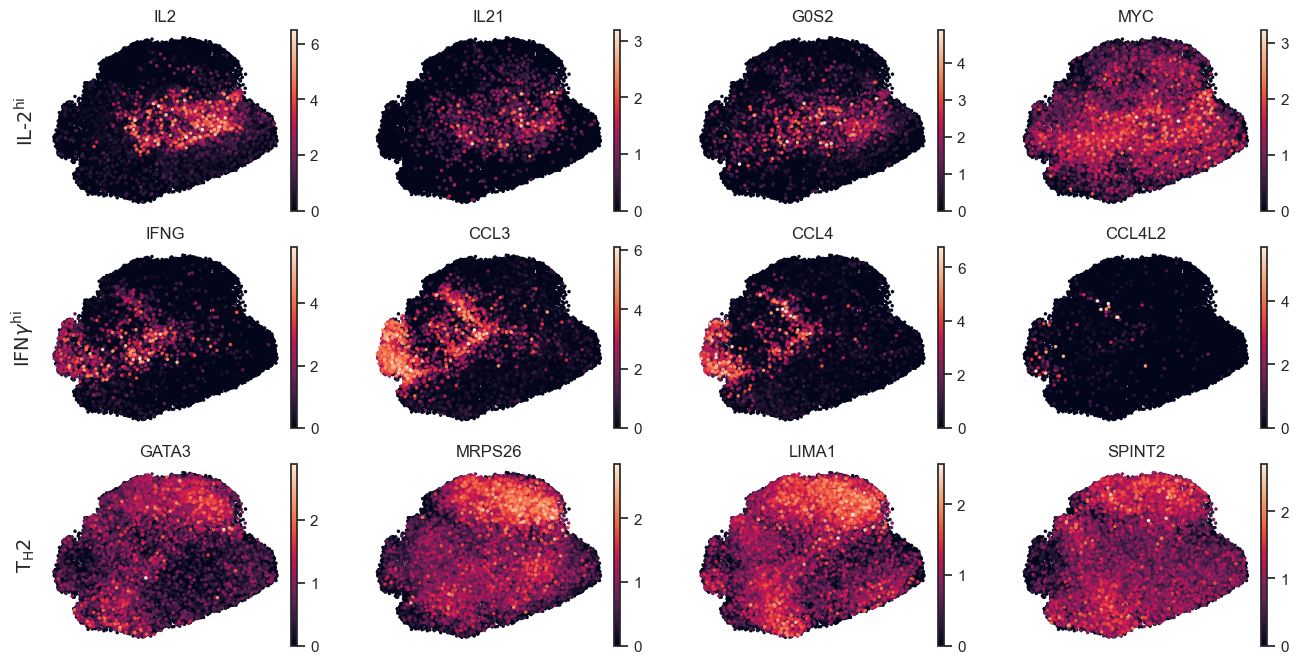

In [75]:
fig, axes = plt.subplots(len(marker_genes), 4, figsize=(16, 8))
for i, (key, value) in enumerate(marker_genes.items()):
    for j in range(4):
        if j >= len(value):
            axes[i, j].axis('off')
            continue
        mkr = value[j]
        sc.pl.embedding(padata_p, basis='umap', color=mkr, size=25, ax=axes[i, j], show=False, cmap='rocket', vmin=0, layer='dy')
        axes[i, j].collections[0].set_rasterized(True)
        axes[i, j].spines['right'].set_visible(False)
        axes[i, j].spines['top'].set_visible(False)
        axes[i, j].spines['bottom'].set_visible(False)
        axes[i, j].spines['left'].set_visible(False)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')
        if j == 0:
            axes[i, j].set_ylabel(key, fontsize=14)
plt.savefig('../figures/3_tcells2_subtype_each_marker.pdf', bbox_inches='tight')
plt.show()

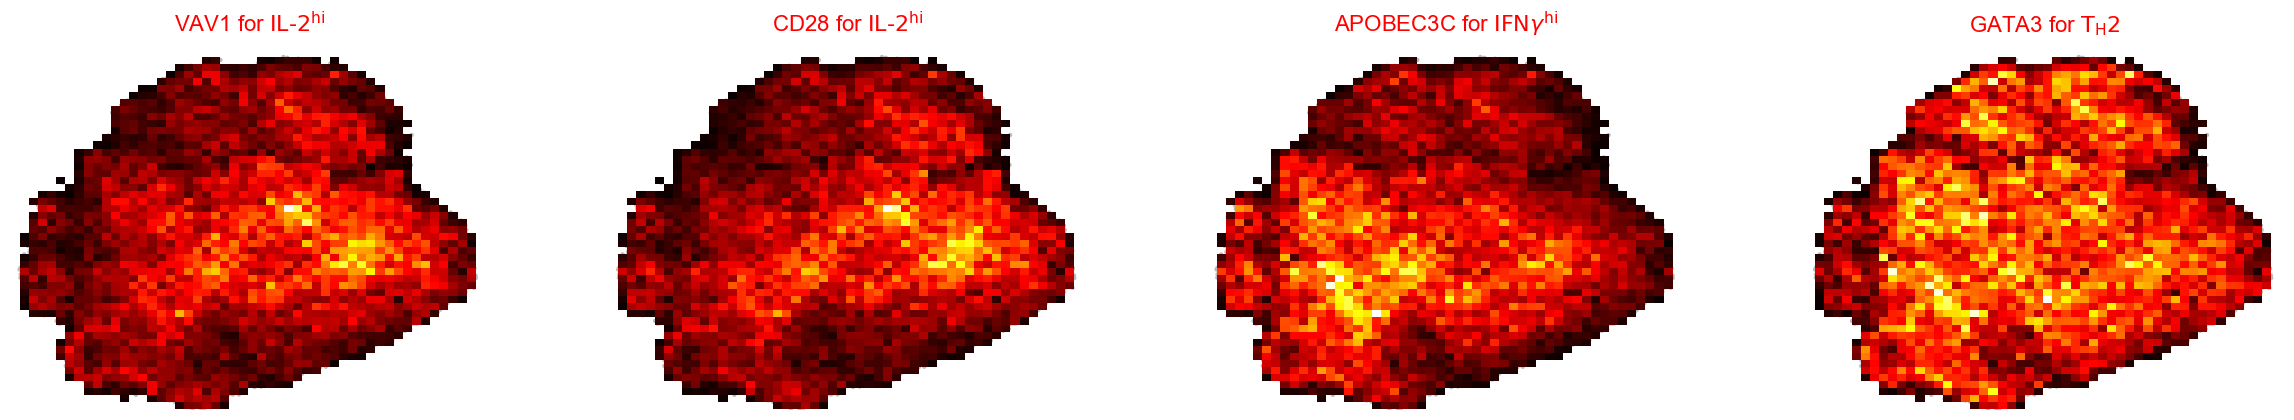

In [50]:
axes = sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['cell.type'] * len(sum(driver_genes.values(), [])), 
    palette=['#bbbbbb'] * 2,
    frameon=False,
    size=40,
    show=False,
    ncols=5
)
emb_umap_all = padata_p.obsm['X_umap']
for ax, gene in zip(axes, sum(driver_genes.values(), [])):
    if ax.collections:
        ax.collections[0].set_rasterized(True)
        
        emb_weights = padata_p.obsm['RelPos'][gene]
        sns.histplot(
            x=emb_umap_all[:, 0],
            y=emb_umap_all[:, 1],
            stat='density',
            bins=50,
            # pthresh=0.1,
            weights=emb_weights,
            fill=True,
            ax=ax,
            cmap='hot',
            # cut=10,
        )
        ax.legend().remove()
        if gene in g2ct:
            ax.set_title(f"{gene} for {g2ct[gene]}", fontsize=16, color='red')
        else:
            ax.set_title(gene, fontsize=10, color='gray')
        ax.set_xlim(emb_umap_all[:, 0].min() * 1.05, emb_umap_all[:, 0].max() * 1.05)
        ax.set_ylim(emb_umap_all[:, 1].min() * 1.05, emb_umap_all[:, 1].max() * 1.05)
plt.tight_layout()
# plt.savefig(f'../figures/3_tcells2_umap_driver_proba.pdf', bbox_inches='tight', dpi=600)
plt.show()


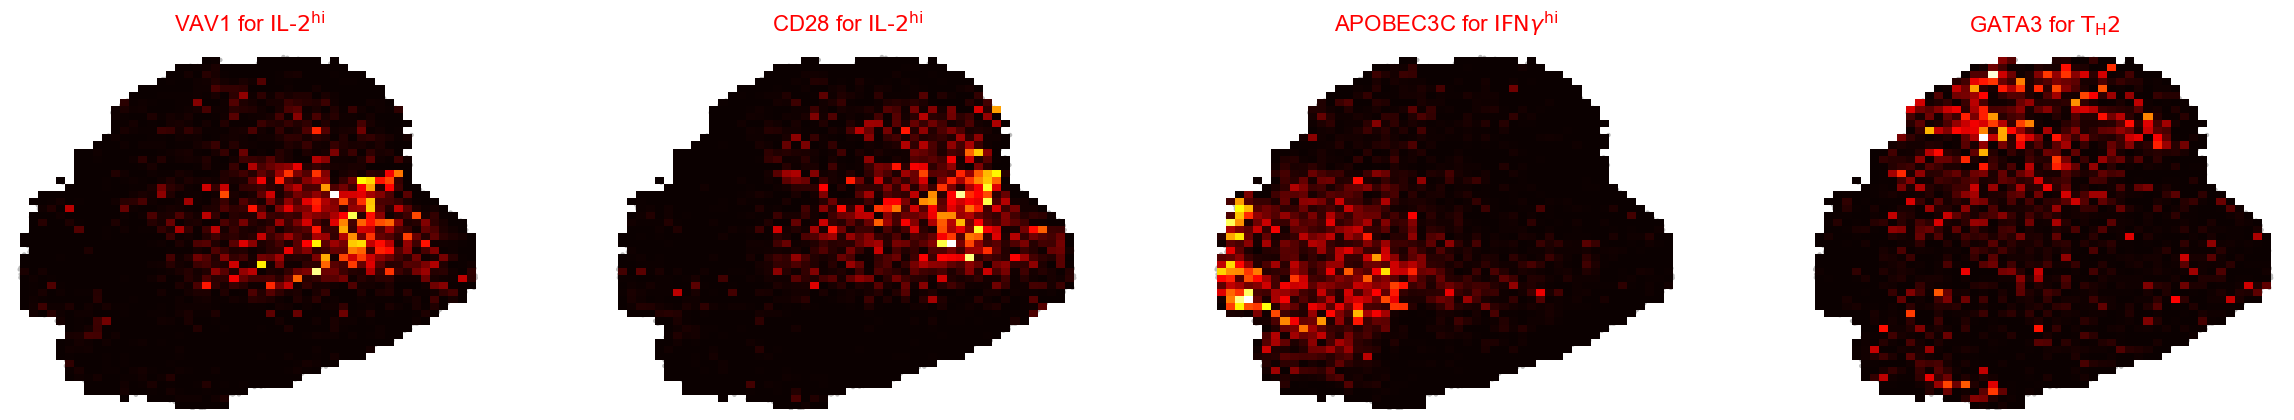

In [51]:
axes = sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['cell.type'] * len(sum(driver_genes.values(), [])), 
    palette=['#bbbbbb'] * 2,
    frameon=False,
    size=40,
    show=False,
    ncols=5
)
emb_umap_all = padata_p.obsm['X_umap']
for ax, gene in zip(axes, sum(driver_genes.values(), [])):
    if ax.collections:
        ax.collections[0].set_rasterized(True)
        
        emb_weights = padata_p.obsm['proba'][gene]
        sns.histplot(
            x=emb_umap_all[:, 0],
            y=emb_umap_all[:, 1],
            stat='density',
            bins=50,
            # pthresh=0.1,
            weights=emb_weights,
            fill=True,
            ax=ax,
            cmap='hot',
            # cut=10,
        )
        ax.legend().remove()
        if gene in g2ct:
            ax.set_title(f"{gene} for {g2ct[gene]}", fontsize=16, color='red')
        else:
            ax.set_title(gene, fontsize=10, color='gray')
        ax.set_xlim(emb_umap_all[:, 0].min() * 1.05, emb_umap_all[:, 0].max() * 1.05)
        ax.set_ylim(emb_umap_all[:, 1].min() * 1.05, emb_umap_all[:, 1].max() * 1.05)
plt.tight_layout()
plt.savefig(f'../figures/3_tcells2_umap_driver_proba.pdf', bbox_inches='tight', dpi=600)
plt.show()


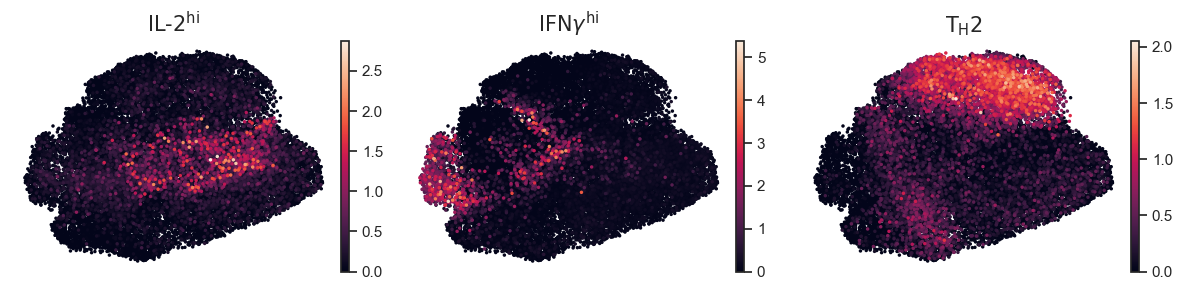

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, (key, value) in enumerate(marker_genes.items()):
    sc.tl.score_genes(padata_p, value, score_name=f'{key} score', layer='dy')
    sc.pl.embedding(
        padata_p, basis='umap', color=f'{key} score', size=25, 
        frameon=False, cmap='rocket', 
        ax=axes[i], show=False, vmin=0
    )
    axes[i].collections[0].set_rasterized(True)
    axes[i].set_title(key, fontsize=15)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.savefig('../figures/3_tcells2_transition_score.pdf', bbox_inches='tight')
plt.show()


In [53]:
padata_p.obs['subtype of interest'] = padata_p.obs['subtype.leiden'].replace('Other', None)
padata_p.obs['subtype of interest'] = \
    pd.Categorical(
        padata_p.obs['subtype of interest'], 
        categories=[
            r'$\text{IL-2}^\text{hi}$', 
            r'$\text{IFN}\gamma^\text{hi}$', 
            r'$\text{T}_\text{H}2$'
        ], 
        ordered=True
    )

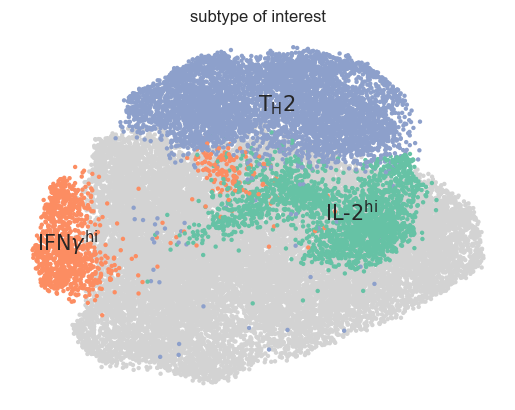

In [54]:
ax = sc.pl.embedding(
    basis='umap',
    adata=padata_p, 
    color='subtype of interest', 
    frameon=False,
    show=False,
    palette=sns.color_palette('Set2', 3),
    size=40,
    legend_loc='on data',
    na_in_legend=False,
    legend_fontsize=15,
)
if ax.collections:
    ax.collections[0].set_rasterized(True)
plt.savefig('../figures/3_tcells2_subtype_scatters.pdf', bbox_inches='tight')
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, mannwhitneyu, ttest_ind

auc_df = pd.DataFrame(
    columns=padata_p.obs['subtype.leiden'].unique(),
    index=padata_p.obsm['proba'].columns
)
spearman_df = pd.DataFrame(
    columns=padata_p.obs['subtype.leiden'].unique(),
    index=padata_p.obsm['proba'].columns
)
pval_df = pd.DataFrame(
    columns=padata_p.obs['subtype.leiden'].unique(),
    index=padata_p.obsm['proba'].columns,
)
for g in padata_p.obsm['proba'].columns:
    for c in padata_p.obs['subtype.leiden'].unique():
        if c == 'Other':
            continue
        auc_df.loc[g, c] = roc_auc_score(
            padata_p.obs['subtype.leiden'] == c, 
            padata_p.obsm['proba'][g]
        )
        spearman_df.loc[g, c] = spearmanr(
            padata_p.obs[f'{c} score'], 
            padata_p.obsm['proba'][g]
        )[0]
        pvals = (
            mannwhitneyu(
                padata_p.obsm['RelPos'][g][padata_p.obs['subtype.leiden'] == c2], 
                padata_p.obsm['RelPos'][g][padata_p.obs['subtype.leiden'] == c],
                alternative='less'
            )[1]
            for c2 in padata_p.obs['subtype.leiden'].unique()
            if c2 != c and c2 != 'Other'
        )
        pval_df.loc[g, c] = max(pvals)
# %%
with pd.ExcelWriter('data/tcells_auc_r_p_df.xlsx') as writer:
    auc_df.to_excel(writer, sheet_name='AUC')
    spearman_df.to_excel(writer, sheet_name='Spearman')
    pval_df.to_excel(writer, sheet_name='pval')


In [56]:
palette = sns.color_palette('Set2', len(driver_genes))
order = [r'$\text{IL-2}^\text{hi}$', r'$\text{IFN}\gamma^\text{hi}$', r'$\text{T}_\text{H}2$']

In [57]:
import scipy.stats as stats
def sci_formatter(x):
    if x < 1e-300:
        return '$p<1\\times 10^{-300}$'
    if x > 0.05:
        return '$p>0.05$'
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    return f'$p={coeff:.1f}\\times 10^{{{exp}}}$'

                                RelPos          
                                  mean       std
subtype of interest                             
$\text{IL-2}^\text{hi}$       0.679075  0.223518
$\text{IFN}\gamma^\text{hi}$  0.442240  0.222957
$\text{T}_\text{H}2$          0.445184  0.249833
                                 proba          
                                  mean       std
subtype of interest                             
$\text{IL-2}^\text{hi}$       0.021246  0.077195
$\text{IFN}\gamma^\text{hi}$  0.004152  0.030133
$\text{T}_\text{H}2$          0.003573  0.019594
                                RelPos          
                                  mean       std
subtype of interest                             
$\text{IL-2}^\text{hi}$       0.750122  0.204134
$\text{IFN}\gamma^\text{hi}$  0.571613  0.225982
$\text{T}_\text{H}2$          0.457621  0.272790
                                 proba          
                                  mean       std
subtype of interest 

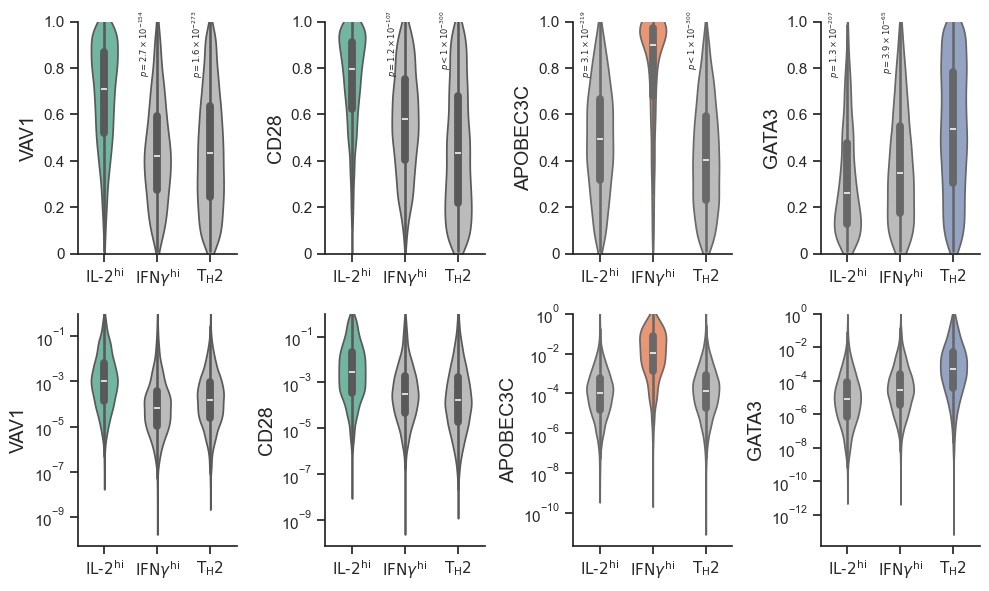

In [93]:
ng_total = sum(len(v) for v in driver_genes.values())
fig, axes = plt.subplots(2, ng_total, figsize=(2.5 * ng_total, 6), sharex=False, sharey=False)
jj = -1
for j, (key, genes) in enumerate(driver_genes.items()):
    for _, g in enumerate(genes):
        jj += 1
        for i, tp in enumerate(['RelPos', 'proba']):
            # ax: plt.Axes = axes[i, j * 2 + jj]
            ax: plt.Axes = axes[i, jj]
            plot_df = padata_p.obsm[tp][g].to_frame(name=tp)
            plot_df['subtype of interest'] = padata_p.obs['subtype of interest']
            plot_df.dropna(inplace=True, axis=0)
            print(plot_df.groupby('subtype of interest', observed=False).agg(['mean', 'std']))
            pval_dict = {
                ct: stats.mannwhitneyu(
                    plot_df.loc[plot_df['subtype of interest'] == ct, tp],
                    plot_df.loc[plot_df['subtype of interest'] == key, tp],
                    alternative='less'
                )[1]
                for ct in order if ct != key
            }
            sns.violinplot(
                x='subtype of interest', 
                y=tp, 
                data=plot_df, 
                ax=ax, 
                hue='subtype of interest',
                palette=[color if ct == key else '#bbbbbb' for ct, color in zip(order, palette)], 
                order=order,
                # showfliers=False,
                # fliersize=1,
                width=0.5,
                log_scale=True if tp == 'proba' else False,
            )
            # ax.ticklabel_format(style='plain', axis='y')
            ax.set_xlabel('')
            ax.set_title('')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_ylabel(g, fontsize=14)

            if tp == 'proba':
                ax.set_ylim(top=1.0)
                continue
            ax.set_ylim(top=ax.get_ylim()[1] * 1.1)
            for ct, pval in pval_dict.items():
                ax.text(
                    x=order.index(ct)-0.1, 
                    y=1.05, 
                    s=sci_formatter(pval), 
                    ha='right', 
                    va='top',
                    fontsize=6,
                    rotation=90,
                )
            ax.set_ylim(0,1)
            ax.set_ylabel(g, fontsize=14)
            ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tight_layout()
plt.savefig('../figures/3_tcells2_driver_violin.pdf', bbox_inches='tight')
plt.show()


In [59]:
# get gradient colors bwteen white and red
from matplotlib.colors import LinearSegmentedColormap
# select a deeper color
import matplotlib.colors as mcolors
# Make the color darker by multiplying its RGB values by a factor < 1 (e.g., 0.6)
from scipy.stats import linregress

colors = sns.color_palette('Set2', 3)
darker_colors = sns.color_palette('Set2', 3, desat=0.3)

In [60]:
linear_plot_df = padata_p.obsm['RelPos'].copy()
linear_plot_df['subtype.leiden'] = padata_p.obs['subtype.leiden']
linear_plot_df[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]] = \
    padata_p.obs[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]]

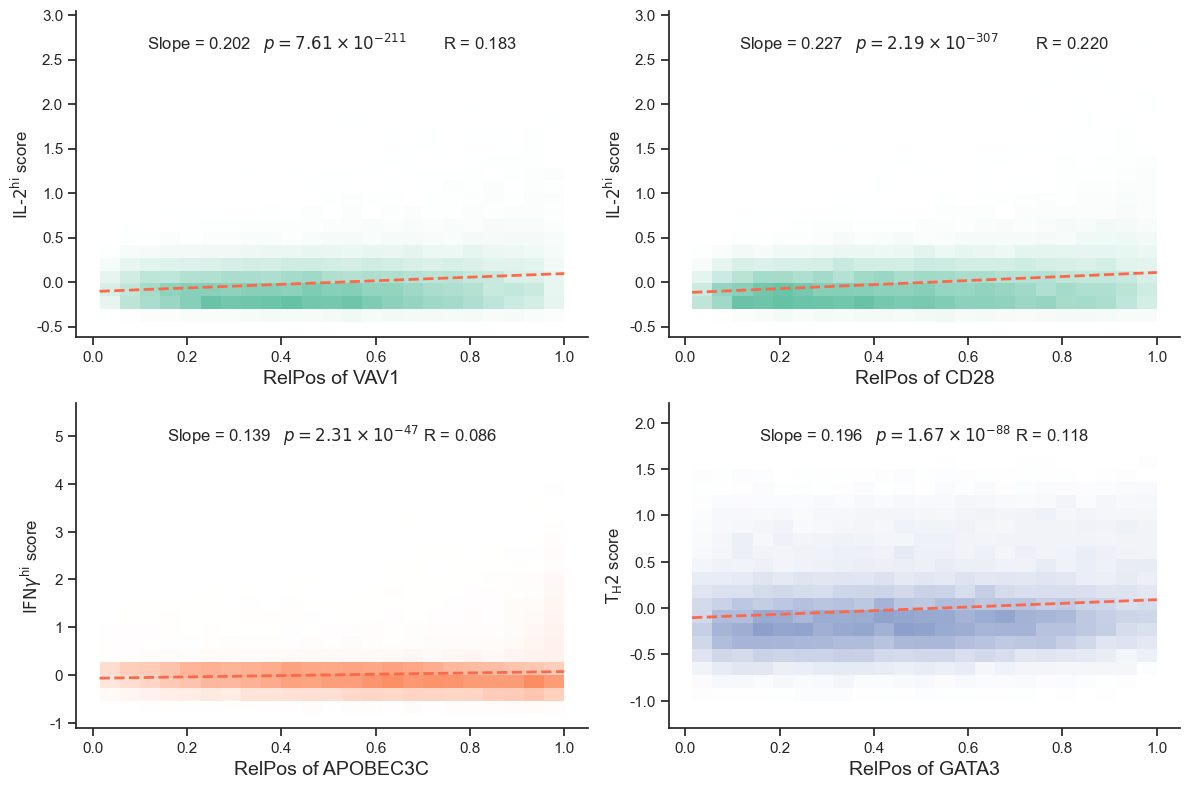

In [78]:
ng_total = sum(len(v) for v in driver_genes.values())
fig, axes = plt.subplots(2, ng_total // 2, figsize=(6 * (ng_total // 2), 8))
axes = axes.flatten()
i = -1
for c, subtype in enumerate(driver_genes.keys()):
    for gene in driver_genes[subtype]:
        i += 1
        x = linear_plot_df[gene].values
        y = linear_plot_df[f'{subtype} score'].values
        cmap = LinearSegmentedColormap.from_list('custom_cmap', ['white', colors[c]])
        sns.histplot(
            data=linear_plot_df,
            y=f'{subtype} score',
            x=gene,
            cmap=cmap,
            bins=23,
            # edgecolor='none',
            # alpha=0.7,
            ax=axes[i],
            stat='density',
            # thresh=0.2,
        )

        # 计算线性回归统计
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        axes[i].plot(x_line, y_line, color=sns.color_palette('Reds', 1)[0], linestyle='--', linewidth=2, label='Fit')
        pv = r'$p=' + rf'{p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'

        axes[i].text(0.5, 0.9, 
            f'Slope = {slope:.3f}\t{pv}\tR = {r_value:.3f}',#\nR = {r_value_spearman:.3f}\n{pv_spearman}',
            transform=axes[i].transAxes,
            fontsize=12,
            verticalalignment='center',
            horizontalalignment='center',
        )
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].set_xlabel(f'RelPos of {gene}', fontsize=14)
plt.tight_layout()
plt.savefig(f'../figures/3_tcells2_hexbin_GATA3_TH2_score.pdf', bbox_inches='tight')
plt.show()

## Benchmark

In [62]:
meta_df = padata_p.obs.copy()
our_proba_df = padata_p.obsm['proba'].copy()
our_relpos_df = (our_proba_df.shape[1] - our_proba_df.rank(axis=1, ascending=False) + 1) / our_proba_df.shape[1]
cellnavi_proba_df = (
    pd
    .read_csv('../3_tcells/data/cellnavi_pred_tcells_results.csv.gz', index_col=0)
    .transform(lambda x: np.exp(x) / np.exp(x).sum(), axis=1)
    .drop(columns=['control'])
)
cellnavi_relpos_df = (cellnavi_proba_df.shape[1] - cellnavi_proba_df.rank(axis=1, ascending=False) + 1) / cellnavi_proba_df.shape[1]

In [63]:
colors = sns.color_palette('Set2', 3)
darker_colors = sns.color_palette('Set2', 3, desat=0.3)

In [64]:
subtype_drivers_dict = {
    r"$\text{IL-2}^\text{hi}$": ['VAV1', 'CD28'],
    r"$\text{IFN}\gamma^\text{hi}$": ['APOBEC3C'],
    r"$\text{T}_\text{H}2$": ['GATA3']
}

In [65]:
drivers_relpos_list = []
for subtype, drivers in subtype_drivers_dict.items():
    cells = meta_df[meta_df['subtype.leiden'] == subtype].index.tolist()
    our_ = our_relpos_df.loc[cells, drivers].copy().assign(method='Ours')
    cellnavi_ = cellnavi_relpos_df.loc[cells, drivers].copy().assign(method='CellNavi')
    drivers_relpos_list.append(pd.concat([our_, cellnavi_]).melt(id_vars='method', var_name='gene', value_name='RelPos').assign(subtype=subtype))
drivers_relpos_df = pd.concat(drivers_relpos_list)



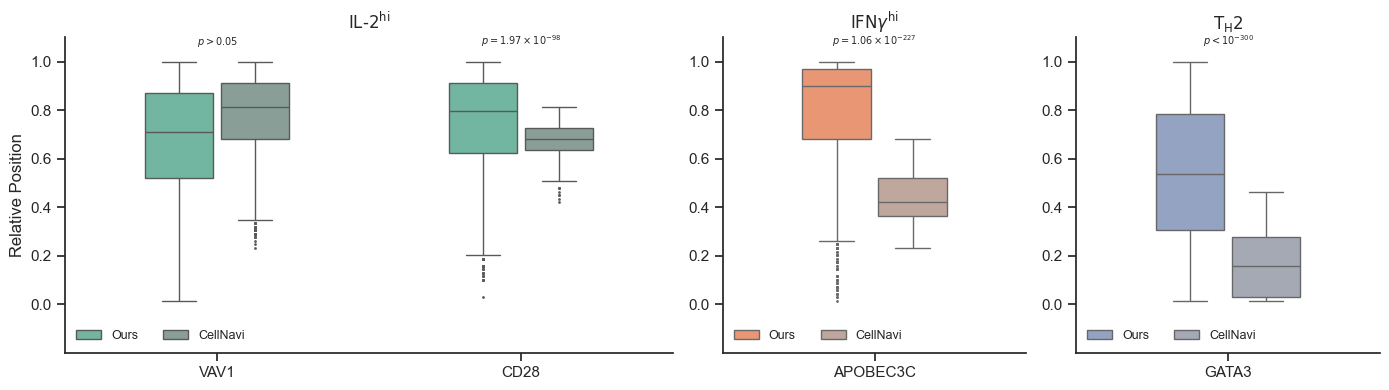

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), width_ratios=[len(v) for v in subtype_drivers_dict.values()])
for i, subtype in enumerate(subtype_drivers_dict.keys()):
    sns.boxplot(
        data=drivers_relpos_df[drivers_relpos_df['subtype'] == subtype],
        x='gene', y='RelPos', hue='method',
        palette=[colors[i], darker_colors[i]],
        ax=axes[i],
        width=0.5,
        gap=0.1,
        fliersize=1,
    )
    axes[i].set_title(subtype)
    axes[i].set_xlabel('')
    if i == 0:
        axes[i].set_ylabel('Relative Position')
    else:
        axes[i].set_ylabel('')
    axes[i].legend(frameon=False, fontsize=9, loc='lower left', ncol=2)
    axes[i].set_ylim(-0.2, 1.1)
    axes[i].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    
    # Add p-values
    for j, gene in enumerate(subtype_drivers_dict[subtype]):
        our_data = drivers_relpos_df.query('subtype == @subtype & gene == @gene & method == "Ours"')['RelPos']
        cellnavi_data = drivers_relpos_df.query('subtype == @subtype & gene == @gene & method == "CellNavi"')['RelPos']
        p_value = mannwhitneyu(our_data, cellnavi_data, alternative='greater')[1]
        # format p-value to scientific notation with x10^
        if p_value > 0.05:
            pv = r'$p> 0.05$'
        elif p_value < 1e-300:
            pv = r'$p<10^{-300}$'
        else:
            pv = r'$p=' + rf'{p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'
        axes[i].text(j, 1.05, pv, ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('../figures/3_tcells2_benchmark_relpos_boxplot.pdf')
plt.show()

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from scipy.stats import mannwhitneyu, spearmanr, pearsonr

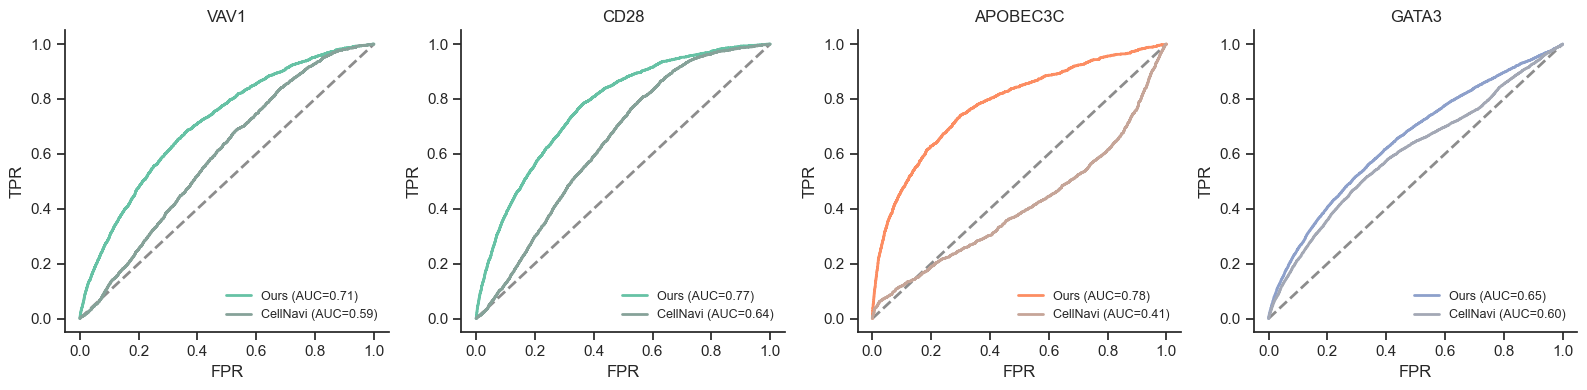

In [97]:
ng_total = sum(len(v) for v in driver_genes.values())
fig, axes = plt.subplots(1, ng_total, figsize=(4 * ng_total, 4))
i = -1
for c, subtype in enumerate(subtype_drivers_dict.keys()):
    cells = meta_df[meta_df['subtype.leiden'] == subtype].index.tolist()
    for gene in subtype_drivers_dict[subtype]:
        i += 1
        our_proba = our_proba_df[gene]
        our_label = our_proba.index.isin(cells)
        cellnavi_proba = cellnavi_proba_df[gene]
        cellnavi_label = cellnavi_proba.index.isin(cells)
        our_fpr, our_tpr, our_thresholds = roc_curve(our_label, our_proba)
        our_auc = auc(our_fpr, our_tpr)
        cellnavi_fpr, cellnavi_tpr, cellnavi_thresholds = roc_curve(cellnavi_label, cellnavi_proba)
        cellnavi_auc = auc(cellnavi_fpr, cellnavi_tpr)
        axes[i].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
        axes[i].plot(our_fpr, our_tpr, label=f'Ours (AUC={our_auc:.2f})', color=colors[c], lw=2)
        axes[i].plot(cellnavi_fpr, cellnavi_tpr, label=f'CellNavi (AUC={cellnavi_auc:.2f})', color=darker_colors[c], lw=2)
        axes[i].set_title(gene)
        axes[i].set_xlabel('FPR')
        axes[i].set_ylabel('TPR')
        axes[i].legend(frameon=False, fontsize=9, loc='lower right')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/3_tcells2_benchmark_roc_curve.pdf')
plt.show()
    

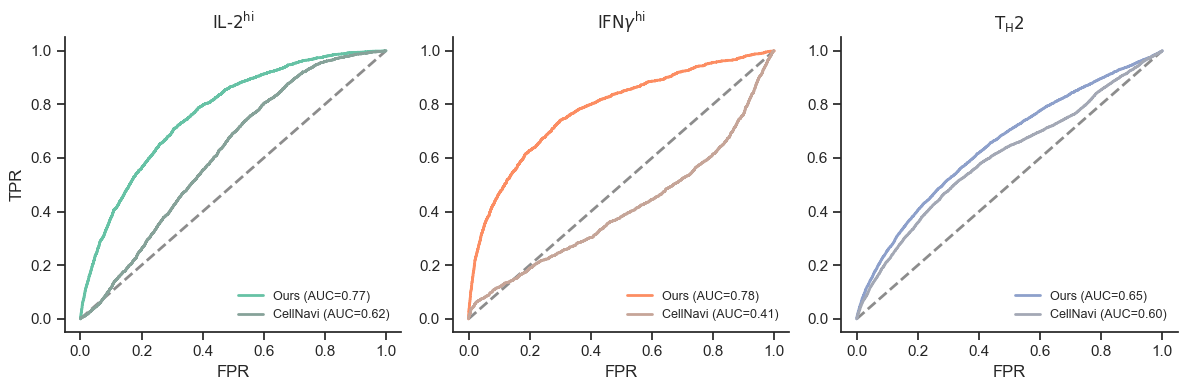

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, subtype in enumerate(subtype_drivers_dict.keys()):
    cells = meta_df[meta_df['subtype.leiden'] == subtype].index.tolist()
    our_proba = our_proba_df[subtype_drivers_dict[subtype]].apply(lambda x: 1 - np.prod(1 - x), axis=1)
    our_label = our_proba.index.isin(cells)
    cellnavi_proba = cellnavi_proba_df[subtype_drivers_dict[subtype]].apply(lambda x: np.prod(x), axis=1)
    cellnavi_label = cellnavi_proba.index.isin(cells)
    our_fpr, our_tpr, our_thresholds = roc_curve(our_label, our_proba)
    our_auc = auc(our_fpr, our_tpr)
    cellnavi_fpr, cellnavi_tpr, cellnavi_thresholds = roc_curve(cellnavi_label, cellnavi_proba)
    cellnavi_auc = auc(cellnavi_fpr, cellnavi_tpr)
    axes[i].plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    axes[i].plot(our_fpr, our_tpr, label=f'Ours (AUC={our_auc:.2f})', color=colors[i], lw=2)
    axes[i].plot(cellnavi_fpr, cellnavi_tpr, label=f'CellNavi (AUC={cellnavi_auc:.2f})', color=darker_colors[i], lw=2)
    axes[i].set_title(subtype)
    axes[i].set_xlabel('FPR')
    if i == 0:
        axes[i].set_ylabel('TPR')
    else:
        axes[i].set_ylabel('')
    axes[i].legend(frameon=False, fontsize=9, loc='lower right')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('../figures/3_tcells_benchmark_roc_curve.pdf')
plt.show()
    

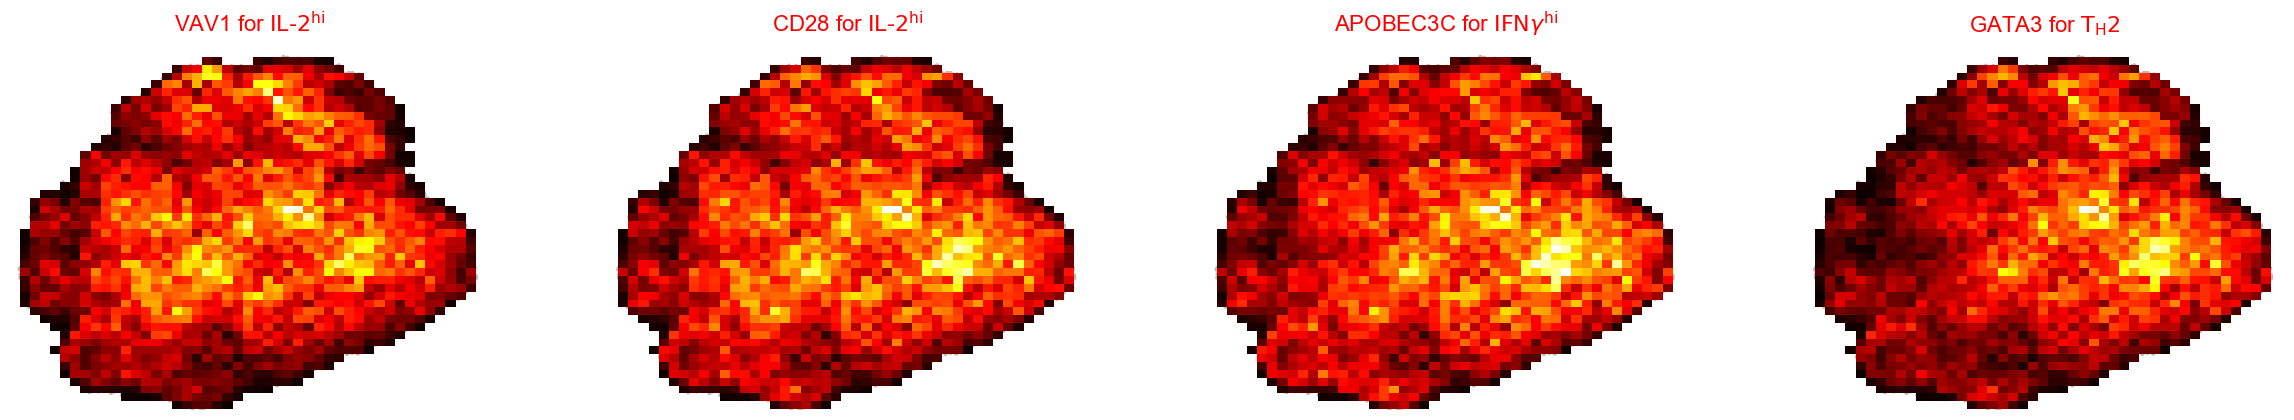

In [70]:
axes = sc.pl.embedding(
    padata_p, 
    basis='umap',
    color=['cell.type'] * len(sum(driver_genes.values(), [])), 
    palette=['#bbbbbb'] * 2,
    frameon=False,
    size=40,
    show=False,
    ncols=5
)
emb_umap_all = padata_p.obsm['X_umap']
for ax, gene in zip(axes, sum(driver_genes.values(), [])):
    if ax.collections:
        ax.collections[0].set_rasterized(True)
        
        emb_weights = cellnavi_proba_df.loc[padata_p.obs_names, gene]
        sns.histplot(
            x=emb_umap_all[:, 0],
            y=emb_umap_all[:, 1],
            stat='density',
            bins=45,
            # pthresh=0.1,
            weights=emb_weights,
            fill=True,
            ax=ax,
            cmap='hot',
            # cut=10,
        )
        ax.legend().remove()
        if gene in g2ct:
            ax.set_title(f"{gene} for {g2ct[gene]}", fontsize=16, color='red')
        else:
            ax.set_title(gene, fontsize=10, color='gray')
        ax.set_xlim(emb_umap_all[:, 0].min() * 1.05, emb_umap_all[:, 0].max() * 1.05)
        ax.set_ylim(emb_umap_all[:, 1].min() * 1.05, emb_umap_all[:, 1].max() * 1.05)
plt.tight_layout()
# plt.savefig(f'../figures/3_tcells_umap_driver_top1.pdf', bbox_inches='tight', dpi=600)
plt.show()


In [71]:
our_linear_plot_df = our_relpos_df.loc[padata_p.obs_names]
our_linear_plot_df['subtype.leiden'] = padata_p.obs['subtype.leiden']
our_linear_plot_df[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]] = \
    padata_p.obs[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]]
cellnavi_linear_plot_df = cellnavi_relpos_df.loc[padata_p.obs_names]
cellnavi_linear_plot_df['subtype.leiden'] = padata_p.obs['subtype.leiden']
cellnavi_linear_plot_df[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]] = \
    padata_p.obs[padata_p.obs.columns[padata_p.obs.columns.str.endswith('score')]]

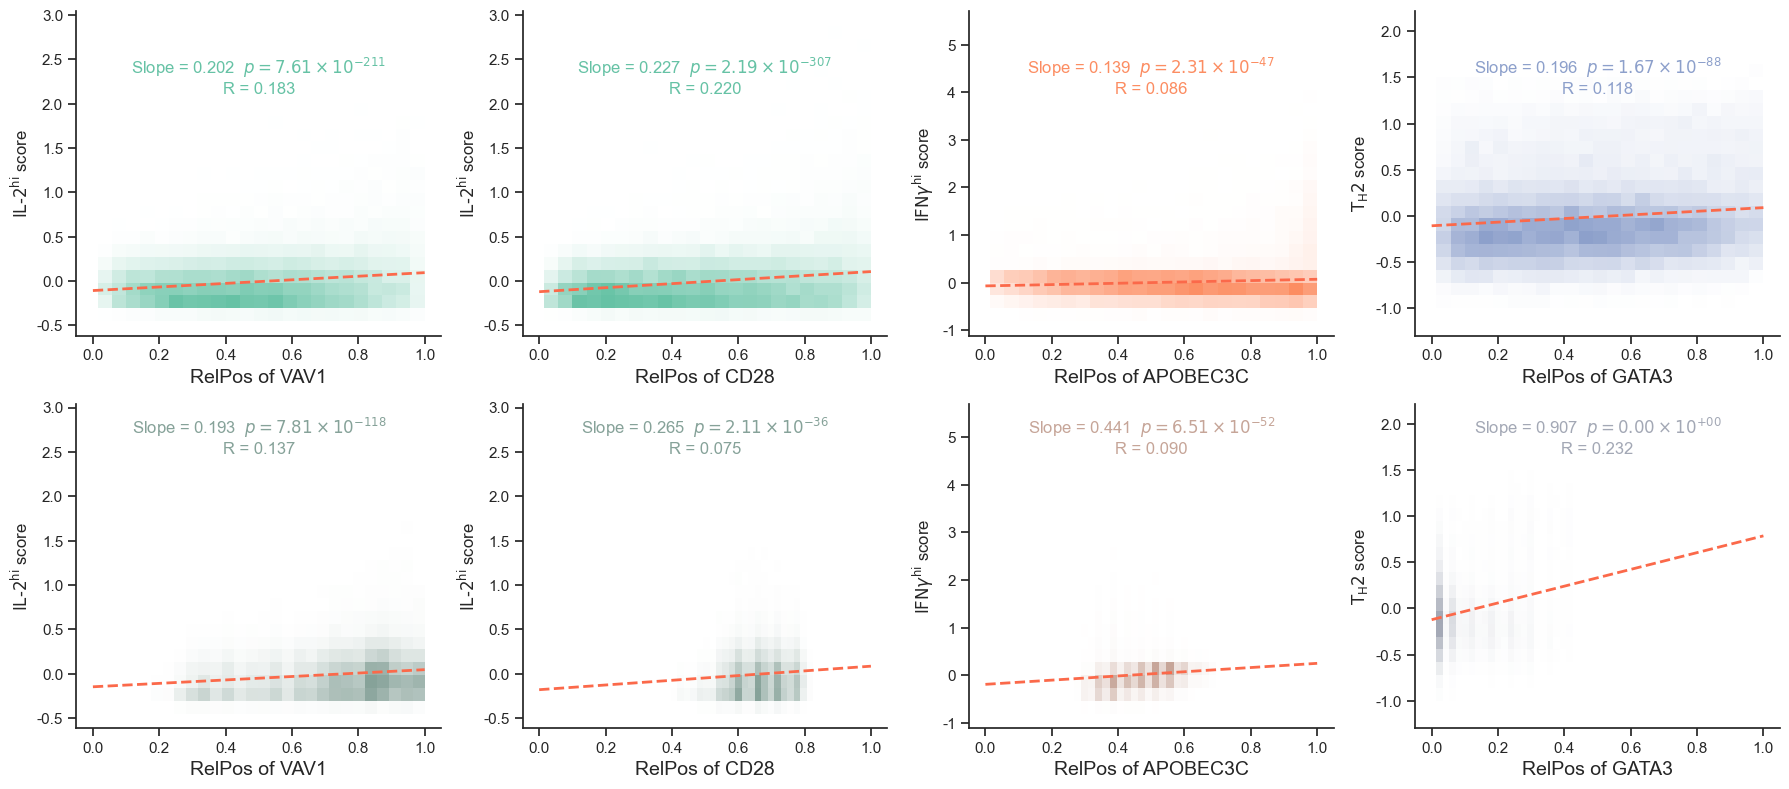

In [85]:
ng_total = sum(len(v) for v in driver_genes.values())
fig, axes = plt.subplots(2, ng_total, figsize=(4.5 * ng_total, 8))
i = -1
for c, subtype in enumerate(driver_genes.keys()):
    for gene in driver_genes[subtype]:
        i += 1
        for m, (mnm, ldf, cmp) in enumerate(zip(['Ours', 'CellNavi'], [our_linear_plot_df, cellnavi_linear_plot_df], [colors, darker_colors])):
            x = ldf[gene].values#[ldf['subtype.leiden'] == subtype]
            y = ldf[f'{subtype} score'].values#[ldf['subtype.leiden'] == subtype]
            cmap = LinearSegmentedColormap.from_list('custom_cmap', ['white', cmp[c]])
            sns.histplot(
                data=ldf,
                y=f'{subtype} score',
                x=gene,
                cmap=cmap,
                bins=23,
                # edgecolor='none',
                # alpha=0.7,
                ax=axes[m, i],
                stat='density',
                # thresh=0.2,
            )

            # 计算线性回归统计
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            # pearsonr_value, pearson_p_value = pearsonr(x, y)
            # spearmanr_value, spearman_p_value = spearmanr(x, y)
            x_line = np.linspace(0.0, 1.0, 100)
            y_line = slope * x_line + intercept
            axes[m, i].plot(x_line, y_line, color=sns.color_palette('Reds', 1)[0], linestyle='--', linewidth=2, label='Fit')
            pv = r'$p=' + rf'{p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'
            # pv = r'$p=' + rf'{spearman_p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'

            axes[m, i].text(0.5, 0.8 + m * 0.1, 
                f'Slope = {slope:.3f}  {pv}\nR = {r_value:.3f}',
                # f'{mnm}: Spearman R = {spearmanr_value:.3f}\t{pv}',
                transform=axes[m, i].transAxes,
                fontsize=12,
                verticalalignment='center',
                horizontalalignment='center',
                color=cmp[c]
            )
            axes[m, i].spines['top'].set_visible(False)
            axes[m, i].spines['right'].set_visible(False)
            axes[m, i].set_xlabel(f'RelPos of {gene}', fontsize=14)
plt.tight_layout()
plt.savefig(f'../figures/3_tcells2_hexbin_GATA3_TH2_score_benchmark.pdf', bbox_inches='tight')
plt.show()

In [73]:
padata_p.write_h5ad('../results/tcells/overlappedgenes2-seed42/anndata/preprocessed_all-plot.h5ad')